# Batch Heuristics Pipeline v3 — corrected scale, robustness suite

**Goal:** produce the activation results, the threshold-robustness evidence and the
validity evidence requested by Reviewer 2 ("thresholds not yet independently
validated; inconsistencies in definitions and units remain").

## What changed relative to v2

| # | Change | Why |
|---|--------|-----|
| 1 | Brake-scale corrections applied **before** any result is produced (`PEDAL_ACTIVE_PCT = 5.0`, `OVERBRAKE_DELTA = 15.0`, `LEGACY_BRAKE_GATE = 5.0`) | v2 audited the scale in §8 but ran §4-§9 with the pre-audit values, so every result was anchored at thresholds the manuscript does not declare |
| 2 | Descriptor parameters (`PEDAL_ACTIVE_PCT`, `MIN_BRAKE_RUN`) moved into `DESC_SPEC` | in v2 these were module constants, invisible to the sensitivity analysis, although the pedal-active threshold is the most influential constant in the pipeline |
| 3 | Two-stage cache: telemetry -> `interp_cache`, descriptors -> `heur_cache(desc_params)` | lets descriptors be recomputed under different `DESC_SPEC` values without reloading `.ibt` files |
| 4 | Explicit legacy-vs-corrected delta table | the size of the correction belongs in the response letter |
| 5 | OAT factor grid widened to 0.25x-3.0x | a wide sweep that preserves the conclusion is stronger evidence than a narrow one; the breaking point of each rule is more informative than its absence |
| 6 | Added joint Monte Carlo perturbation (all thresholds at once) | under OAT, 10 of 12 rule counts are unchanged by construction, so Kendall tau is near 1 regardless of robustness |
| 7 | `pattern_ok` binary replaced by continuous slope margins | True/False collapses the effect size and hides how close a scenario came to flipping |
| 8 | Descriptor-level sweep of `PEDAL_ACTIVE_PCT` and `MIN_BRAKE_RUN` | closes the gap in item 2 |
| 9 | Negative control and convergent validity recomputed under both threshold sets | tests whether the scale correction improved specificity |

**Run order:** §1 -> §11 top to bottom. §4 loads telemetry once; everything after
that is cheap.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# notebook lives in Iracing/Notebooks/ -> go up one level
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                    basic_clean_and_units, build_lap_validity_table, load_stint)

RNG = np.random.default_rng(20250813)   # reproducible Monte Carlo

print(f"Tracks : {list(TRACK_CONFIGS.keys())}")
print(f"Drivers: {DRIVER_ALIAS}")

Tracks : ['charlotte_roval_2025', 'summit_point']
Drivers: {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}


## 2. Batch configuration

`COMPARISONS`: chained proficiency comparisons — **not** a single global reference.

- **B vs. A** (intermediate vs. expert)
- **C vs. B**, **D vs. B**, **E vs. B**, **F vs. B** (each amateur vs. the intermediate)

Driver A never appears as `test`; Driver B never appears as `ref` in the amateur group.

In [2]:
COMPARISONS = [
    {"ref": "Rodrigo",     "ref_stint": "stint_1",   "test": "Tomaz",      "label": "B vs. A"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Morsinaldo", "label": "C vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Thallys",    "label": "D vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Igor",       "label": "E vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Hilton",     "label": "F vs. B"},
]
comp_order = [c["label"] for c in COMPARISONS]

EXCLUDE_STINTS = {"warmup", "stint_ref"}
TRACK_SHORT    = {"charlotte_roval_2025": "CLT", "summit_point": "SPT"}
BASE_GRID_LEN  = 2000

# Longitudinal design: pairs that received feedback vs. the untreated control.
FEEDBACK_PAIRS = ["B vs. A", "C vs. B", "D vs. B", "F vs. B"]
CONTROL_PAIR   = "E vs. B"

SAVE_DIR = Path(PROJECT_ROOT) / "img" / "batch_heuristics_v3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {SAVE_DIR}")

Output directory: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_heuristics_v3


## 3. Descriptors — parameterized

**Unit convention (single source of truth; Table 2 of the manuscript must match):**

| Quantity | Unit |
|---|---|
| Pedal inputs (brake, throttle) | % on a 0–100 scale |
| Lap distance (`LapDistPct`) | fraction, 0–1 |
| Time | s |
| Speed | km/h |
| Steering angle | rad |
| Yaw rate | rad/s |
| Longitudinal acceleration | m/s² |

`DESC_SPEC` holds the two descriptor-level constants. In v2 these were hard-coded
(`0.05`, meaning 0.05 % on a 0–100 channel — pedal noise). They are now explicit
parameters so §10 can sweep them.

`PEDAL_ACTIVE_PCT` feeds four descriptors (`BrakeStartDist`, `BrakeEfficiency`,
`BrakeRampRate`, `BrakeConsistency`) plus the throttle mask, which is why it cannot
be swept through `TH` alone — it changes the descriptors themselves, not the rules.

In [3]:
# --- Descriptor-level parameters ---------------------------------------------
DESC_SPEC = {
    "PEDAL_ACTIVE_PCT": 5.0,   # %  -- pedal considered engaged (masks M_b, M_t)
    "MIN_BRAKE_RUN":    5,     # consecutive samples on the 2000-pt/lap grid
}

# Pre-correction values, kept only to quantify the effect of the fix (§5).
DESC_LEGACY = {
    "PEDAL_ACTIVE_PCT": 0.05,  # 0.05 % on a 0-100 channel -> pedal noise
    "MIN_BRAKE_RUN":    5,
}

EPS = 1e-6


def compute_derivatives(sec):
    """Pedal rates in %/s, Savitzky-Golay smoothed (window <= 9, order 3)."""
    t  = sec["t_rel"]
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    brake_rate    = np.gradient(sec["brake"], dt)
    throttle_rate = np.gradient(sec["throttle"], dt)
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate    = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)
    return brake_rate, throttle_rate


def braking_heuristics(sec, brake_rate, dp):
    """M_b = {i : b_i > PEDAL_ACTIVE_PCT}. Sector without braking -> zeros."""
    d = {}
    m = sec["brake"] > dp["PEDAL_ACTIVE_PCT"]
    if np.any(m):
        d["BrakeRampRate"]    = float(np.quantile(brake_rate[m], 0.95))    # %/s
        d["BrakeConsistency"] = float(np.var(brake_rate[m]))               # (%/s)^2
        d["BrakeEfficiency"]  = float(abs(np.min(sec["long_accel"][m])) /
                                      (np.max(sec["brake"][m]) + EPS))     # m/s^2 per %
    else:
        d["BrakeRampRate"] = d["BrakeConsistency"] = d["BrakeEfficiency"] = 0.0
    return d


def brake_start_dist(sec, dp):
    """Lap fraction of the first sustained brake application in the sector.
    Sustained = b > PEDAL_ACTIVE_PCT for MIN_BRAKE_RUN consecutive samples.
    NaN when the sector contains no sustained braking."""
    n  = int(dp["MIN_BRAKE_RUN"])
    on = sec["brake"] > dp["PEDAL_ACTIVE_PCT"]
    if on.size < n or not np.any(on):
        return np.nan
    runs = np.convolve(on.astype(int), np.ones(n, dtype=int), mode="valid")
    idx  = np.flatnonzero(runs == n)
    return float(sec["lap_pct"][idx[0]]) if idx.size else np.nan


def rotation_heuristics(sec):
    d = {}
    speed, yaw, steer, t = sec["speed"], sec["yaw_rate"], sec["steering"], sec["t_rel"]
    idx_vmin = np.argmin(speed)
    idx_mrp  = np.argmax(np.abs(yaw))
    d["Vmin"] = float(speed[idx_vmin])                                     # km/h
    # t(Vmin) - t(MRP), in s. Negative => peak rotation occurs AFTER the
    # minimum-speed point (late rotation).
    d["Delta_MRP_Vmin"] = float(t[idx_vmin] - t[idx_mrp])                  # s
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    d["TrailOverlap"] = float((sec["brake"] * np.abs(steer) * dt).sum())   # %.rad.s
    d["Vmin_Norm"]    = float(d["Vmin"] / (speed[0] + EPS))                # -
    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = (float(np.mean(np.abs(yaw)) / (avg_steer + EPS))
                               if avg_steer > 1e-3 else 0.0)               # s^-1
    return d


def acceleration_heuristics(sec, throttle_rate, dp):
    """M_t = {i : t_i > PEDAL_ACTIVE_PCT}."""
    d = {}
    m = sec["throttle"] > dp["PEDAL_ACTIVE_PCT"]
    if np.any(m):
        d["ThrottleAttackRate"]    = float(np.quantile(throttle_rate[m], 0.95))    # %/s
        d["ThrottleSmoothness"]    = float(1.0 / (np.var(throttle_rate[m]) + EPS)) # (%/s)^-2
        d["ThrottleSteerConflict"] = float(np.mean(sec["throttle"] *
                                                   np.abs(sec["steering"])))       # %.rad
        d["AccelEfficiency"]       = float(np.mean(sec["long_accel"][m]) /
                                           (np.mean(sec["throttle"][m]) + EPS))    # m/s^2 per %
    else:
        d["ThrottleAttackRate"] = d["ThrottleSmoothness"] = 0.0
        d["ThrottleSteerConflict"] = d["AccelEfficiency"] = 0.0
    return d


def sector_heuristics(sec_raw, dp):
    sec = {
        "t_rel":      sec_raw["t_rel"],
        "speed":      sec_raw["speed"],
        "brake":      sec_raw["brake"],
        "throttle":   sec_raw["throttle"],
        "steering":   sec_raw["SteeringWheelAngle"],
        "yaw_rate":   sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
        "lap_pct":    sec_raw["LapDistPct"],
    }
    brake_rate, throttle_rate = compute_derivatives(sec)
    h = {
        "SpeedStart":     float(sec["speed"][0]),                        # km/h
        "SpeedEnd":       float(sec["speed"][-1]),                       # km/h
        "BrakePeak":      float(np.max(sec["brake"])),                   # %
        "SteerRMS":       float(np.sqrt(np.mean(sec["steering"] ** 2))), # rad
        "BrakeStartDist": brake_start_dist(sec, dp),                     # lap fraction
    }
    h.update(braking_heuristics(sec, brake_rate, dp))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate, dp))
    return h


def compute_sector_heuristics(interp, edges, dp):
    if not interp:
        return pd.DataFrame()
    lap_dist = interp["LapDistPct"]
    rows = []
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i + 1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i + 1])
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            continue
        sl = slice(idx[0], idx[-1] + 1)
        sec_raw = {k: v[sl] for k, v in interp.items()}
        sec_raw["t_rel"] = sec_raw["t_rel"] - sec_raw["t_rel"][0]
        h = sector_heuristics(sec_raw, dp)
        h["Sector"]       = i
        h["SectorTime_s"] = float(sec_raw["t_rel"][-1])
        rows.append(h)
    return pd.DataFrame(rows)

In [4]:
# --- Lap alignment (unchanged from v2) ---------------------------------------
def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray):
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}
    interp = lambda y: np.interp(grid, x, y)
    return {
        "LapDistPct": grid,
        "t_rel":      interp(t_rel.to_numpy()),
        "speed":      interp(g["Speed_KPH"].to_numpy()),
        "throttle":   interp(g["Throttle_Pct"].to_numpy()),
        "brake":      interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":    interp(g.get("YawRate",   pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":  interp(g.get("LongAccel", pd.Series(np.zeros_like(x))).to_numpy()),
    }


def assert_pedal_scale(interp, name="lap"):
    """Fail loudly if the pedal channels are not on a 0-100 scale.
    Every absolute brake threshold in THRESHOLD_SPEC assumes percent."""
    for ch in ("brake", "throttle"):
        vmax = float(np.max(interp[ch]))
        if vmax <= 1.5:
            raise ValueError(
                f"[{name}] channel '{ch}' peaks at {vmax:.3f}: looks like a 0-1 scale. "
                f"All thresholds assume 0-100. Fix basic_clean_and_units() or rescale.")
    return True

## 4. `DRIVING_RULES` — parameterized thresholds

`THRESHOLD_SPEC` stores each numeric trigger as `(neutral, margin)`:

$$\theta(f) = \text{neutral} + \text{margin}\times f, \qquad f=1 \text{ at baseline}$$

`neutral` is the value at which the rule loses meaning (1 for ratios, 0 for additive
margins), so scaling the margin preserves each rule's semantics. This matters: a naive
±50 % on `VMIN_RATIO = 0.97` would sweep 0.485–1.455, which is physically meaningless;
scaling the margin sweeps 0.985–0.955 instead.

**Corrections applied to the baseline (were wrong in v2):**

| Parameter | v2 | v3 | Reason |
|---|---|---|---|
| `OVERBRAKE_DELTA` | 0.15 | **15.0** | 0.15 p.p. on a 0–100 channel is pedal noise; Table 3 states +15 p.p. |
| `LEGACY_BRAKE_GATE` | 0.05 | **5.0** | 0.05 % is pedal noise; Table 3 states 5 % |

`ENTRY_BRAKE_GATE = 5.0` was already consistent. All ratio parameters are
scale-invariant and unchanged.

In [5]:
THRESHOLD_SPEC = {
    # name               (neutral, margin)   unit / consumer
    'MRP_DT':            (0.0,  -0.05),   # s            - LATE_ROTATION
    'BRAKE_EFF_RATIO':   (1.0,  -0.15),   # ratio (0.85) - LOW_BRAKE_EFFICIENCY
    'TRAIL_RATIO':       (1.0,  -0.30),   # ratio (0.70) - POOR_TRAIL_BRAKING
    'LEGACY_DV':         (0.0,  -2.0),    # km/h         - EXIT_SPEED_LEGACY
    'LEGACY_BRAKE_GATE': (0.0,   5.0),    # %  [FIXED v3] - EXIT_SPEED_LEGACY
    'BRAKE_DIST_TOL':    (0.0,   0.005),  # lap fraction - BRAKING_POINT_MISMATCH
    'OVERBRAKE_DELTA':   (0.0,  15.0),    # p.p. [FIXED v3] - OVER_BRAKING_PEAK
    'ENTRY_SLOW_REL':    (0.0,  -0.015),  # relative     - ENTRY_OVER_SLOW
    'ENTRY_BRAKE_GATE':  (0.0,   5.0),    # %            - ENTRY_OVER_SLOW
    'RAMP_RATIO':        (1.0,   0.25),   # ratio (1.25) - AGGRESSIVE_UNSTABLE_BRAKE
    'CONS_RATIO':        (1.0,   0.30),   # ratio (1.30) - AGGRESSIVE_UNSTABLE_BRAKE
    'STEER_RMS_RATIO':   (1.0,   0.20),   # ratio (1.20) - STEER_EFFICIENCY
    'ROTEFF_DIFF':       (0.0,  -0.05),   # s^-1         - ROTATION_INEFFICIENT
    'VMIN_RATIO':        (1.0,  -0.03),   # ratio (0.97) - ROTATION_INEFFICIENT
    'SMOOTH_RATIO':      (1.0,  -0.20),   # ratio (0.80) - LATE_THROTTLE_LOW_SPEED
    'EXIT_DV':           (0.0,  -1.0),    # km/h         - LATE_THROTTLE_LOW_SPEED
    'CONFLICT_RATIO':    (1.0,   0.20),   # ratio (1.20) - THROTTLE_STEER_CONFLICT
}

# Pre-correction spec, used only for the legacy-vs-corrected delta in section 5.
THRESHOLD_SPEC_LEGACY = dict(THRESHOLD_SPEC,
                             OVERBRAKE_DELTA=(0.0, 0.15),
                             LEGACY_BRAKE_GATE=(0.0, 0.05))


def thresholds_at(factors=None, spec=None):
    """Effective thresholds; `factors` maps parameter name -> scale factor."""
    spec = spec or THRESHOLD_SPEC
    factors = factors or {}
    return {k: n + m * factors.get(k, 1.0) for k, (n, m) in spec.items()}


TH = thresholds_at()   # baseline, factor = 1.0 everywhere

DRIVING_RULES = [
    # ---- Braking ------------------------------------------------------------
    {"id": "BRAKING_POINT_MISMATCH", "category": "Braking", "params": ["BRAKE_DIST_TOL"],
     "condition": lambda A, B: (np.isfinite(A.get("BrakeStartDist", np.nan)) and
                                np.isfinite(B.get("BrakeStartDist", np.nan)) and
                                abs(B["BrakeStartDist"] - A["BrakeStartDist"]) > TH['BRAKE_DIST_TOL'])},

    {"id": "OVER_BRAKING_PEAK", "category": "Braking", "params": ["OVERBRAKE_DELTA"],
     "condition": lambda A, B: B.get("BrakePeak", 0) > A.get("BrakePeak", 0) + TH['OVERBRAKE_DELTA']},

    {"id": "LOW_BRAKE_EFFICIENCY", "category": "Braking", "params": ["BRAKE_EFF_RATIO"],
     "condition": lambda A, B: B.get("BrakeEfficiency", 0) <
                               A.get("BrakeEfficiency", 0) * TH['BRAKE_EFF_RATIO']},

    {"id": "AGGRESSIVE_UNSTABLE_BRAKE", "category": "Braking", "params": ["RAMP_RATIO", "CONS_RATIO"],
     "condition": lambda A, B: ((B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + EPS)) > TH['RAMP_RATIO'] and
                                (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + EPS)) > TH['CONS_RATIO'])},

    {"id": "ENTRY_OVER_SLOW", "category": "Braking", "params": ["ENTRY_SLOW_REL", "ENTRY_BRAKE_GATE"],
     "condition": lambda A, B: (((B.get("Vmin", 1) - A.get("Vmin", 1)) /
                                 (A.get("Vmin", 1) + EPS)) < TH['ENTRY_SLOW_REL'] and
                                B.get("BrakePeak", 0) > TH['ENTRY_BRAKE_GATE'])},

    # ---- Rotation -----------------------------------------------------------
    {"id": "LATE_ROTATION", "category": "Rotation", "params": ["MRP_DT"],
     "condition": lambda A, B: B.get("Delta_MRP_Vmin", 0) < TH['MRP_DT']},

    {"id": "POOR_TRAIL_BRAKING", "category": "Rotation", "params": ["TRAIL_RATIO"],
     "condition": lambda A, B: (B.get("TrailOverlap", 0) < A.get("TrailOverlap", 0) * TH['TRAIL_RATIO'] and
                                B.get("Vmin", 0) < A.get("Vmin", 0))},

    {"id": "STEER_EFFICIENCY", "category": "Rotation", "params": ["STEER_RMS_RATIO"],
     "condition": lambda A, B: B.get("SteerRMS", 0) > A.get("SteerRMS", 0) * TH['STEER_RMS_RATIO']},

    {"id": "ROTATION_INEFFICIENT", "category": "Rotation", "params": ["ROTEFF_DIFF", "VMIN_RATIO"],
     "condition": lambda A, B: ((B.get("RotationEfficiency", 0) -
                                 A.get("RotationEfficiency", 0) < TH['ROTEFF_DIFF']) and
                                (B.get("Vmin", 0) < A.get("Vmin", 0) * TH['VMIN_RATIO']))},

    # ---- Traction -----------------------------------------------------------
    {"id": "THROTTLE_STEER_CONFLICT", "category": "Traction", "params": ["CONFLICT_RATIO"],
     "condition": lambda A, B: B.get("ThrottleSteerConflict", 0) >
                               A.get("ThrottleSteerConflict", 0) * TH['CONFLICT_RATIO']},

    {"id": "LATE_THROTTLE_LOW_SPEED", "category": "Traction", "params": ["SMOOTH_RATIO", "EXIT_DV"],
     "condition": lambda A, B: ((B.get("ThrottleSmoothness", 1) <
                                 A.get("ThrottleSmoothness", 1) * TH['SMOOTH_RATIO']) and
                                (B.get("SpeedEnd", 0) < A.get("SpeedEnd", 0) + TH['EXIT_DV']))},

    # ---- Legacy -------------------------------------------------------------
    {"id": "EXIT_SPEED_LEGACY", "category": "Legacy", "params": ["LEGACY_DV", "LEGACY_BRAKE_GATE"],
     "condition": lambda A, B: (B.get("SpeedStartDiff", 0) < TH['LEGACY_DV'] and
                                B.get("BrakePeak", 0) < TH['LEGACY_BRAKE_GATE'])},
]

RULE_IDS   = [r["id"] for r in DRIVING_RULES]
RULE_CAT   = {r["id"]: r["category"] for r in DRIVING_RULES}
PARAM_RULES = {}
for r in DRIVING_RULES:
    for p in r["params"]:
        PARAM_RULES.setdefault(p, []).append(r["id"])

print(f"{len(DRIVING_RULES)} rules, {len(THRESHOLD_SPEC)} tunable thresholds, "
      f"{len(DESC_SPEC)} descriptor parameters.")
print("Baseline thresholds:")
for k, v in thresholds_at().items():
    print(f"  {k:20s} = {v:>9.4g}")

12 rules, 17 tunable thresholds, 2 descriptor parameters.
Baseline thresholds:
  MRP_DT               =     -0.05
  BRAKE_EFF_RATIO      =      0.85
  TRAIL_RATIO          =       0.7
  LEGACY_DV            =        -2
  LEGACY_BRAKE_GATE    =         5
  BRAKE_DIST_TOL       =     0.005
  OVERBRAKE_DELTA      =        15
  ENTRY_SLOW_REL       =    -0.015
  ENTRY_BRAKE_GATE     =         5
  RAMP_RATIO           =      1.25
  CONS_RATIO           =       1.3
  STEER_RMS_RATIO      =       1.2
  ROTEFF_DIFF          =     -0.05
  VMIN_RATIO           =      0.97
  SMOOTH_RATIO         =       0.8
  EXIT_DV              =        -1
  CONFLICT_RATIO       =       1.2


## 5. Batch engine — two-stage cache

v2 loaded telemetry and computed descriptors in a single pass, which froze
`DESC_SPEC` into the results. v3 splits the two:

1. `interp_cache[(track, driver, stint)]` — aligned channels, loaded **once**.
2. `build_heur_cache(dp)` — descriptors under a given `DESC_SPEC`, cheap to recompute.

This makes the legacy-vs-corrected comparison (§6) and the descriptor sweep (§10)
possible without touching the `.ibt` files again.

In [6]:
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

interp_cache = {}   # (track, driver, stint) -> aligned channels
lap_records  = []   # best-lap bookkeeping for the manuscript appendix
_scale_checked = False


def load_best_lap_interp(track, driver, stint):
    """Load a stint, keep the fastest valid lap, return aligned channels."""
    global _scale_checked
    key = (track, driver, stint)
    if key in interp_cache:
        return interp_cache[key]
    files  = [str(p) for p in resolve_stint_files(track, driver, stint)]
    raw    = load_stint(files)
    df     = basic_clean_and_units(raw)
    lap_df = build_lap_validity_table(df)
    valid  = lap_df[lap_df["Valid"]]
    if valid.empty:
        raise RuntimeError(f"No valid lap: {track}/{driver}/{stint}")
    best_row = valid.sort_values("LapTime_s").iloc[0]
    g = df[df["Lap"] == int(best_row["Lap"])]
    interp = align_lap_by_dist(g, grid)
    if not _scale_checked:
        assert_pedal_scale(interp, f"{track}/{driver}/{stint}")
        print(f"[SCALE] pedal channels confirmed on a 0-100 scale "
              f"(brake max = {np.max(interp['brake']):.1f} %)")
        _scale_checked = True
    interp_cache[key] = (interp, float(best_row["LapTime_s"]), int(best_row["Lap"]))
    return interp_cache[key]


# --- Stage 1: load every lap referenced by the comparison design ---------------
PLAN = []   # (track, TrackShort, label, stint, ref_driver, ref_stint, test_driver)
for track, cfg in DATASETS.items():
    for comp in COMPARISONS:
        if comp["test"] not in cfg["sessions"] or comp["ref"] not in cfg["sessions"]:
            print(f"[SKIP] {track}: {comp['label']} - driver not present on this track")
            continue
        for stint in sorted(k for k in cfg["sessions"][comp["test"]] if k not in EXCLUDE_STINTS):
            PLAN.append((track, TRACK_SHORT[track], comp["label"], stint,
                         comp["ref"], comp["ref_stint"], comp["test"]))

for track, tshort, label, stint, ref_d, ref_s, test_d in PLAN:
    for drv, stn in ((ref_d, ref_s), (test_d, stint)):
        try:
            _, lt, lap = load_best_lap_interp(track, drv, stn)
        except Exception as e:
            print(f"[SKIP] {track}/{drv}/{stn} -> {e}")
    try:
        lt, lap = interp_cache[(track, test_d, stint)][1:]
        lap_records.append({"Track": tshort, "Comparison": label, "Stint": stint,
                            "BestLap": lap, "LapTime_s": lt})
    except (KeyError, ValueError):
        pass

df_laps = pd.DataFrame(lap_records)
print(f"\n{len(interp_cache)} laps cached, {len(PLAN)} comparison-stints planned.")


# --- Stage 2: descriptors under a given DESC_SPEC ------------------------------
def build_heur_cache(dp):
    """(TrackShort, label, stint) -> (heur_ref, heur_test) under descriptor params dp."""
    out, ref_memo = {}, {}
    for track, tshort, label, stint, ref_d, ref_s, test_d in PLAN:
        if (track, ref_d, ref_s) not in interp_cache or (track, test_d, stint) not in interp_cache:
            continue
        edges = TRACK_CONFIGS[track]["custom_edges"]
        rkey = (track, ref_d, ref_s)
        if rkey not in ref_memo:
            ref_memo[rkey] = compute_sector_heuristics(interp_cache[rkey][0], edges, dp)
        heur_t = compute_sector_heuristics(interp_cache[(track, test_d, stint)][0], edges, dp)
        out[(tshort, label, stint)] = (ref_memo[rkey], heur_t)
    return out


def build_pair_cache(heur_cache):
    """Merge ref/test descriptors per sector -> list of (sector, A, B, delta_t)."""
    pair = {}
    for key, (hr, ht) in heur_cache.items():
        m = pd.merge(hr, ht, on="Sector", suffixes=("_A", "_B"))
        rows = []
        for _, row in m.iterrows():
            A = {k[:-2]: v for k, v in row.items() if k.endswith("_A")}
            B = {k[:-2]: v for k, v in row.items() if k.endswith("_B")}
            B["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)
            dts = float(row.get("SectorTime_s_B", np.nan)) - float(row.get("SectorTime_s_A", np.nan))
            rows.append((int(row["Sector"]), A, B, dts))
        pair[key] = rows
    return pair


def evaluate_rules(pair_cache, th):
    """Activation table under thresholds th. Rules read the global TH at call time."""
    global TH
    th_saved, TH = TH, th
    try:
        rows = []
        for (track, label, stint), pairs in pair_cache.items():
            for sector, A, B, _ in pairs:
                for rule in DRIVING_RULES:
                    try:
                        fired = bool(rule["condition"](A, B))
                    except Exception:
                        fired = False
                    rows.append({"Track": track, "Comparison": label, "Stint": stint,
                                 "Sector": sector, "Rule_ID": rule["id"],
                                 "Category": rule["category"], "Fired": int(fired)})
        return pd.DataFrame(rows)
    finally:
        TH = th_saved


heur_cache = build_heur_cache(DESC_SPEC)
pair_cache = build_pair_cache(heur_cache)
df_sector  = evaluate_rules(pair_cache, thresholds_at())

df_long = (df_sector.groupby(["Track", "Comparison", "Stint", "Rule_ID", "Category"],
                             as_index=False)["Fired"].sum())
df_long.to_csv(SAVE_DIR / "heuristic_activations_long.csv", index=False)
df_laps.to_csv(SAVE_DIR / "best_laps_per_stint.csv", index=False)

print(f"{len(pair_cache)} comparison-stints, "
      f"{sum(len(v) for v in pair_cache.values())} sector pairs.")
print(f"Total activations (corrected baseline): {int(df_long['Fired'].sum())}")

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (45 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 36 laps
  🏆 Fastest : Lap 12  (01:35.483)
  ❌ Invalid : 9 laps
     Lap   0  67:44.283  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=4064.3s | GPS=1.0%<100%
     Lap   6  02:06.883  → StartPct=0.065>0.02 | LapTime=126.9s | GPS=94.0%<100%
     Lap   7  01:46.383  → IQR_outlier
     Lap  10  03:38.083  → LapTime=218.1s
     Lap  13  01:55.917  → IQR_outlier
     Lap  19  01:45.283  → IQR_outlier
     Lap  29  01:45.633  → GPS=99.0%<100%
     Lap  30  03:05.333  → FracLowSpeed=0.43 | LapTime=185.3s
     Lap  44  01:45.850  → IQR_outlier
──────────────────────────────────────────────────────────────
[SCALE] pedal channels confirmed on a 0-100 scale (brake max = 73.

## 6. Scale audit and the legacy-vs-corrected delta

Two things are reported here, both destined for the response letter:

1. **Empirical confirmation** of the channel scales, from the descriptors themselves.
2. **How much the correction changed the results.** Reviewers respond better to a
   quantified correction than to a silent one, and the delta shows which rules were
   actually affected.

In [7]:
# --- Empirical scale verdict ---------------------------------------------------
all_frames = pd.concat(
    [ht.assign(_key=str(k)) for k, (hr, ht) in heur_cache.items()] +
    [hr.assign(_key=str(k) + "_ref") for k, (hr, ht) in heur_cache.items()],
    ignore_index=True)

bp = all_frames["BrakePeak"].dropna()
sr = all_frames["SteerRMS"].dropna()

print("=== Observed descriptor ranges across all cached laps ===")
print(f"BrakePeak : max={bp.max():.3f}  p95={bp.quantile(.95):.3f}  median={bp.median():.3f}")
print(f"SteerRMS  : max={sr.max():.3f}  p95={sr.quantile(.95):.3f}  median={sr.median():.3f}")

brake_scale = ("0-100 (percent)" if bp.max() > 50 else
               "0-1 (fraction)"  if bp.max() <= 1.5 else
               f"ambiguous (max={bp.max():.2f})")
ang_scale   = "rad" if sr.max() < 12 else "deg"
print(f"\nVERDICT: brake channel = {brake_scale} | steering = {ang_scale}")
print("-> Table 2 and Table 3 of the manuscript must state this convention explicitly.")


# --- Legacy vs corrected -------------------------------------------------------
heur_legacy = build_heur_cache(DESC_LEGACY)
pair_legacy = build_pair_cache(heur_legacy)
df_legacy   = evaluate_rules(pair_legacy, thresholds_at(spec=THRESHOLD_SPEC_LEGACY))

cmp_rules = pd.DataFrame({
    "Legacy (v2)":    df_legacy.groupby("Rule_ID")["Fired"].sum(),
    "Corrected (v3)": df_sector.groupby("Rule_ID")["Fired"].sum(),
}).fillna(0).astype(int)
cmp_rules["Delta"]   = cmp_rules["Corrected (v3)"] - cmp_rules["Legacy (v2)"]
cmp_rules["Delta_%"] = (100 * cmp_rules["Delta"] /
                        cmp_rules["Legacy (v2)"].replace(0, np.nan)).round(1)
cmp_rules = cmp_rules.sort_values("Corrected (v3)", ascending=False)

print("\n=== Activation counts: pre-correction vs corrected ===")
display(cmp_rules)
print(f"Total: {cmp_rules['Legacy (v2)'].sum()} -> {cmp_rules['Corrected (v3)'].sum()}")
cmp_rules.to_csv(SAVE_DIR / "legacy_vs_corrected_activations.csv")

=== Observed descriptor ranges across all cached laps ===
BrakePeak : max=100.000  p95=88.602  median=5.555
SteerRMS  : max=2.329  p95=1.062  median=0.317

VERDICT: brake channel = 0-100 (percent) | steering = rad
-> Table 2 and Table 3 of the manuscript must state this convention explicitly.

=== Activation counts: pre-correction vs corrected ===


,Legacy (v2),Corrected (v3),Delta,Delta_%
Rule_ID,,,,
LATE_ROTATION,333,333,0,0.0
ENTRY_OVER_SLOW,236,236,0,0.0
LATE_THROTTLE_LOW_SPEED,171,165,-6,-3.5
EXIT_SPEED_LEGACY,156,163,7,4.5
STEER_EFFICIENCY,162,162,0,0.0
ROTATION_INEFFICIENT,132,132,0,0.0
THROTTLE_STEER_CONFLICT,128,128,0,0.0
OVER_BRAKING_PEAK,227,119,-108,-47.6
AGGRESSIVE_UNSTABLE_BRAKE,115,112,-3,-2.6


Total: 1944 -> 1815


## 7. Snapshot — Stint 1 (Table 7 replacement)

Rows sorted by global frequency (descending); columns grouped by track.

In [8]:
snap = (df_long[df_long["Stint"] == "stint_1"]
        .pivot_table(index="Rule_ID", columns=["Track", "Comparison"],
                     values="Fired", aggfunc="sum", fill_value=0))
snap = snap.reindex(columns=[(t, c) for t in ["CLT", "SPT"] for c in comp_order
                             if (t, c) in snap.columns])
snap = snap.loc[snap.sum(axis=1).sort_values(ascending=False).index]
snap

Track                         CLT                                     SPT  \
Comparison                B vs. A C vs. B D vs. B E vs. B F vs. B B vs. A   
Rule_ID                                                                     
LATE_ROTATION                   9      10       6       5       9       7   
ENTRY_OVER_SLOW                 5       6      11       7       7       4   
LATE_THROTTLE_LOW_SPEED         2       3       7      10       4       3   
EXIT_SPEED_LEGACY               2       2       7       6       5       1   
ROTATION_INEFFICIENT            3       3       6       5       5       3   
STEER_EFFICIENCY                4       3       2       2       4       6   
AGGRESSIVE_UNSTABLE_BRAKE       4       3       2       3       1       1   
OVER_BRAKING_PEAK               5       4       2       0       5       1   
THROTTLE_STEER_CONFLICT         5       4       2       0       3       4   
POOR_TRAIL_BRAKING              3       3       3       3       2       1   
LOW_BRAKE_EFFICIENCY            2       4       2       3       4       1   
BRAKING_POINT_MISMATCH          1       2       3       2       0       2   

Track                                                      
Comparison                C vs. B D vs. B E vs. B F vs. B  
Rule_ID                                                    
LATE_ROTATION                   6       6       5       4  
ENTRY_OVER_SLOW                 2       3       2       5  
LATE_THROTTLE_LOW_SPEED         2       3       5       5  
EXIT_SPEED_LEGACY               2       3       5       4  
ROTATION_INEFFICIENT            3       2       4       0  
STEER_EFFICIENCY                5       1       5       1  
AGGRESSIVE_UNSTABLE_BRAKE       3       3       3       3  
OVER_BRAKING_PEAK               2       1       2       3  
THROTTLE_STEER_CONFLICT         3       1       2       0  
POOR_TRAIL_BRAKING              3       0       3       3  
LOW_BRAKE_EFFICIENCY            1       0       1       0  
BRAKING_POINT_MISMATCH          1       1       1       0

In [9]:
def to_latex_table7(pivot: pd.DataFrame) -> str:
    """Booktabs LaTeX table for the manuscript (Entropy/MDPI style)."""
    tracks  = pivot.columns.get_level_values(0).unique().tolist()
    header1 = " & " + " & ".join(
        f"\\multicolumn{{{sum(pivot.columns.get_level_values(0) == t)}}}{{c}}{{{t}}}"
        for t in tracks) + " \\\\"
    cmid, start = [], 2
    for t in tracks:
        n = sum(pivot.columns.get_level_values(0) == t)
        cmid.append(f"\\cmidrule(lr){{{start}-{start + n - 1}}}")
        start += n
    header2 = "Heuristic & " + " & ".join(c[1] for c in pivot.columns) + " \\\\"

    lines = [
        "\\begin{table}[H]",
        "\\caption{Consolidated heuristic activation frequencies across chained driver",
        "comparisons in Stint 1 (CLT: Charlotte Roval, SPT: Summit Point). Each amateur",
        "driver (C--F) is compared against the intermediate reference (Driver B), and",
        "Driver B is compared against the expert reference (Driver A).",
        "\\label{tab:heuristics_stint1}}",
        "\\centering",
        "\\begin{tabular}{l" + "c" * pivot.shape[1] + "}",
        "\\toprule",
        header1, " ".join(cmid), header2,
        "\\midrule",
    ]
    for rid, row in pivot.iterrows():
        rid_tex = "\\texttt{" + rid.replace("_", "\\_") + "}"
        lines.append(rid_tex + " & " + " & ".join(str(int(v)) for v in row) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    return "\n".join(lines)


latex_out = to_latex_table7(snap)
(SAVE_DIR / "table7_stint1.tex").write_text(latex_out, encoding="utf-8")
print(latex_out)

\begin{table}[H]
\caption{Consolidated heuristic activation frequencies across chained driver
comparisons in Stint 1 (CLT: Charlotte Roval, SPT: Summit Point). Each amateur
driver (C--F) is compared against the intermediate reference (Driver B), and
Driver B is compared against the expert reference (Driver A).
\label{tab:heuristics_stint1}}
\centering
\begin{tabular}{lcccccccccc}
\toprule
 & \multicolumn{5}{c}{CLT} & \multicolumn{5}{c}{SPT} \\
\cmidrule(lr){2-6} \cmidrule(lr){7-11}
Heuristic & B vs. A & C vs. B & D vs. B & E vs. B & F vs. B & B vs. A & C vs. B & D vs. B & E vs. B & F vs. B \\
\midrule
\texttt{LATE\_ROTATION} & 9 & 10 & 6 & 5 & 9 & 7 & 6 & 6 & 5 & 4 \\
\texttt{ENTRY\_OVER\_SLOW} & 5 & 6 & 11 & 7 & 7 & 4 & 2 & 3 & 2 & 5 \\
\texttt{LATE\_THROTTLE\_LOW\_SPEED} & 2 & 3 & 7 & 10 & 4 & 3 & 2 & 3 & 5 & 5 \\
\texttt{EXIT\_SPEED\_LEGACY} & 2 & 2 & 7 & 6 & 5 & 1 & 2 & 3 & 5 & 4 \\
\texttt{ROTATION\_INEFFICIENT} & 3 & 3 & 6 & 5 & 5 & 3 & 3 & 2 & 4 & 0 \\
\texttt{STEER\_EFFICIENCY}

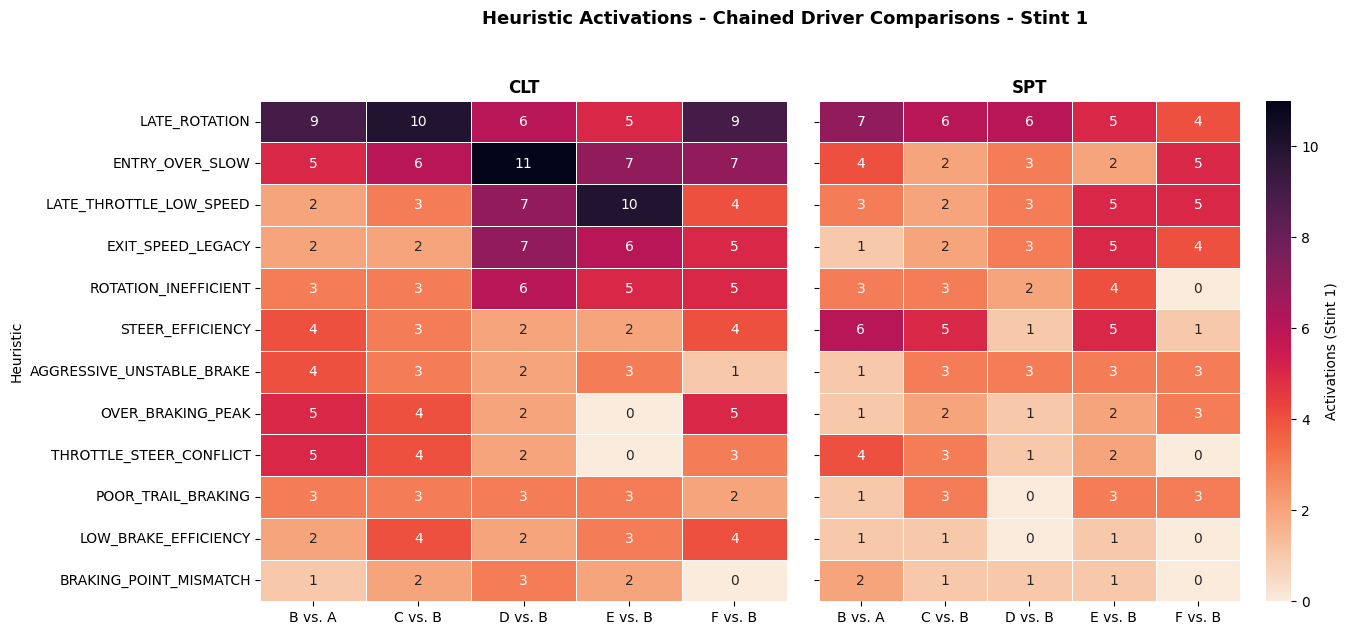

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True,
                         gridspec_kw={"wspace": 0.06,
                                      "width_ratios": [snap["CLT"].shape[1] if "CLT" in snap else 1,
                                                       snap["SPT"].shape[1] if "SPT" in snap else 1]})
vmax = snap.values.max()
for ax, track in zip(axes, ["CLT", "SPT"]):
    sns.heatmap(snap[track], annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax,
                cbar=(track == "SPT"), ax=ax, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Activations (Stint 1)"})
    ax.set_title(track, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Heuristic" if track == "CLT" else "")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Heuristic Activations - Chained Driver Comparisons - Stint 1",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig(SAVE_DIR / "fig_heuristics_stint1_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 8. Longitudinal analysis — activations along stints

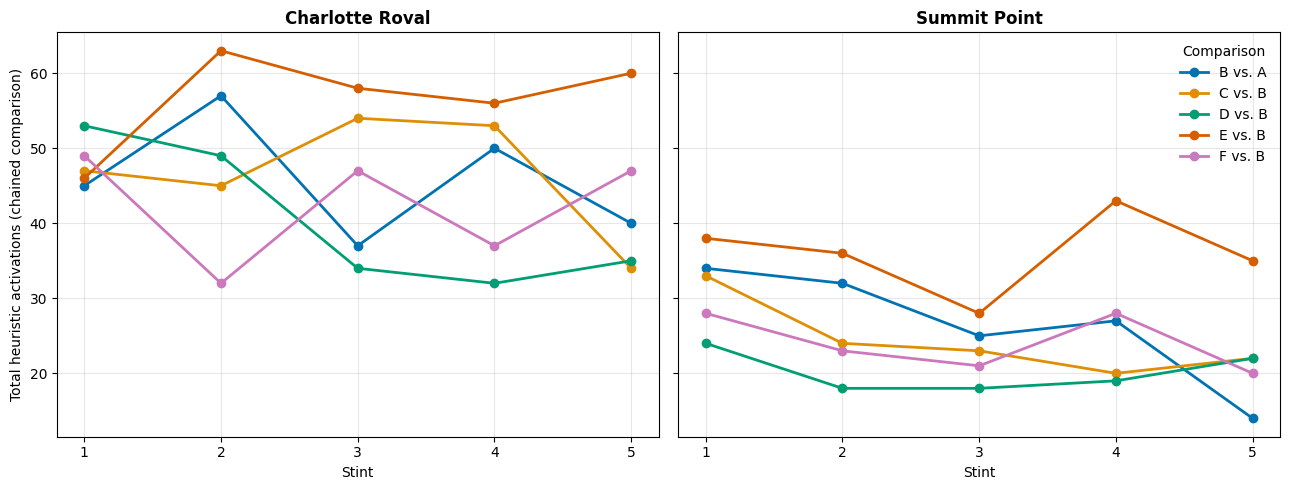

StintN               1     2     3     4     5
Track Comparison                              
CLT   B vs. A     45.0  57.0  37.0  50.0  40.0
      C vs. B     47.0  45.0  54.0  53.0  34.0
      D vs. B     53.0  49.0  34.0  32.0  35.0
      E vs. B     46.0  63.0  58.0  56.0  60.0
      F vs. B     49.0  32.0  47.0  37.0  47.0
SPT   B vs. A     34.0  32.0  25.0  27.0  14.0
      C vs. B     33.0  24.0  23.0  20.0  22.0
      D vs. B     24.0  18.0  18.0  19.0  22.0
      E vs. B     38.0  36.0  28.0  43.0  35.0
      F vs. B     28.0  23.0  21.0  28.0  20.0

In [11]:
tot = df_long.groupby(["Track", "Comparison", "Stint"], as_index=False)["Fired"].sum()
tot["StintN"] = tot["Stint"].str.extract(r"(\d+)").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
palette = dict(zip(comp_order, sns.color_palette("colorblind", len(comp_order))))
for ax, track in zip(axes, ["CLT", "SPT"]):
    sub = tot[tot["Track"] == track]
    for comp, g in sub.groupby("Comparison"):
        g = g.sort_values("StintN")
        ax.plot(g["StintN"], g["Fired"], marker="o", linewidth=2,
                color=palette[comp], label=comp)
    ax.set_title({"CLT": "Charlotte Roval", "SPT": "Summit Point"}[track],
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Stint")
    ax.set_xticks(sorted(sub["StintN"].unique()))
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Total heuristic activations (chained comparison)")
axes[1].legend(title="Comparison", frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig_activations_per_stint_lines.pdf", dpi=300, bbox_inches="tight")
plt.show()

tot.pivot_table(index=["Track", "Comparison"], columns="StintN", values="Fired")

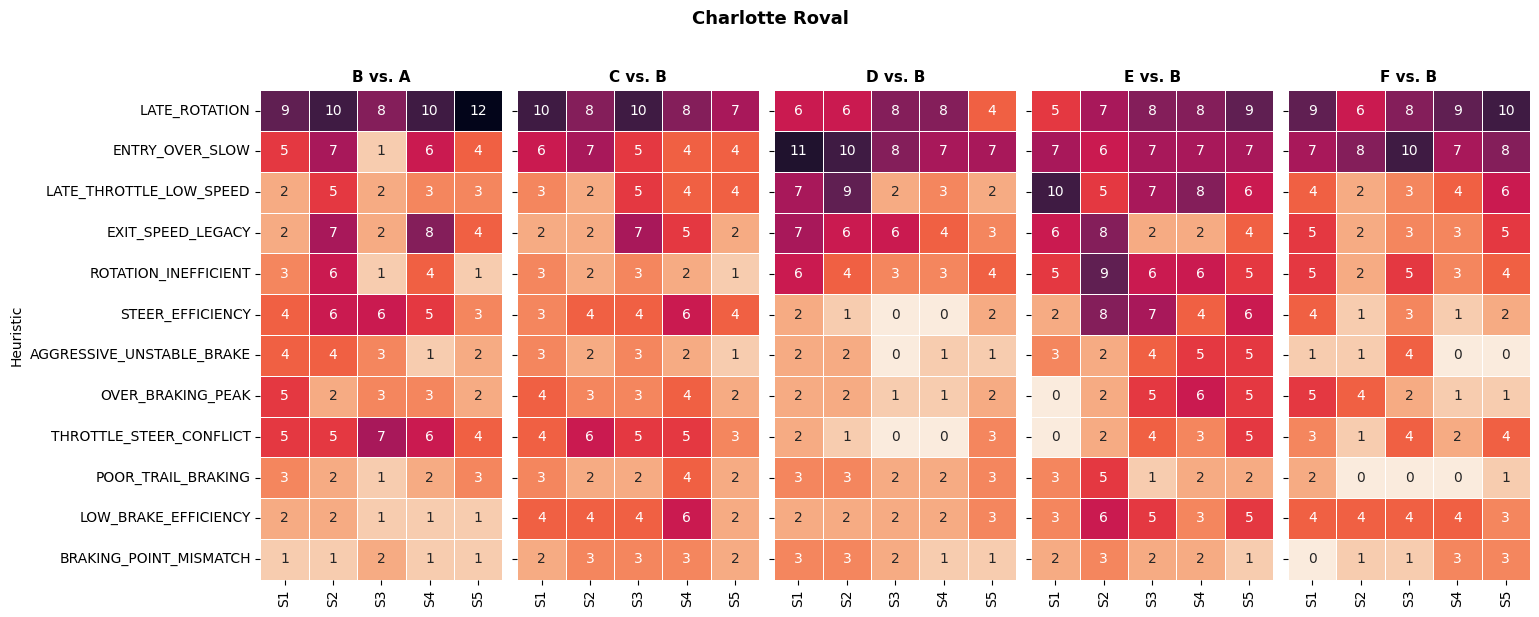

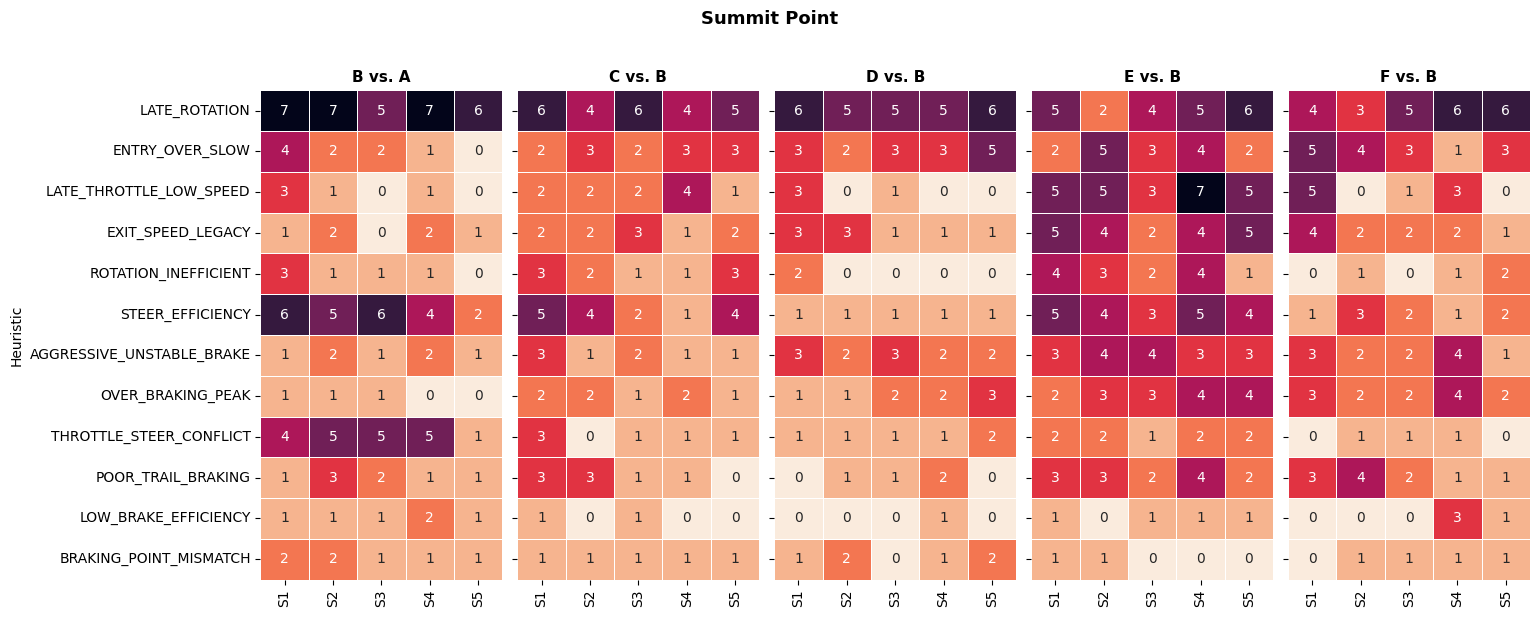

In [12]:
for track in ["CLT", "SPT"]:
    sub = df_long[df_long["Track"] == track]
    comps = [c for c in comp_order if c in sub["Comparison"].unique()]
    fig, axes = plt.subplots(1, len(comps), figsize=(3.1 * len(comps), 6), sharey=True)
    if len(comps) == 1:
        axes = [axes]
    vmax = sub["Fired"].max()
    for ax, comp in zip(axes, comps):
        piv = (sub[sub["Comparison"] == comp]
               .pivot_table(index="Rule_ID", columns="Stint", values="Fired", fill_value=0)
               .reindex(snap.index))
        sns.heatmap(piv, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=vmax,
                    cbar=False, ax=ax, linewidths=0.5, linecolor="white")
        ax.set_title(comp, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Heuristic" if ax is axes[0] else "")
        ax.set_xticklabels([c.get_text().replace("stint_", "S") for c in ax.get_xticklabels()])
    fig.suptitle("Charlotte Roval" if track == "CLT" else "Summit Point",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"fig_heuristics_stints_{track.lower()}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

## 9. Threshold sensitivity

Two complementary designs, because neither is sufficient alone.

**One-at-a-time (§9.2).** Perturbs one threshold at a time. Good for locating the
breaking point of each individual rule, but a poor global stability measure: with 17
parameters each feeding 1–2 of 12 rules, at least 10 rule counts are *identical* to
baseline in every OAT scenario, so a rank correlation against baseline is close to 1
by construction. Reported here with that caveat stated explicitly.

**Joint Monte Carlo (§9.4).** Draws all 17 factors simultaneously from
$\mathcal{U}(0.5, 1.5)$. Every rule moves at once, so the rank correlation and the
longitudinal trend are genuinely stressed. This is the number that belongs in the
response letter.

**Stability criteria.** Rather than a binary flag, the longitudinal pattern is
summarised by two continuous quantities:

- `slope_fb` — mean per-stint slope of the feedback pairs (expected negative);
- `margin` — `slope_ctrl - slope_fb` (expected positive; how far the control sits
  above the treated pairs).

A scenario "preserves the pattern" when `slope_fb < 0` and `margin > 0`, but the
magnitudes are what get reported.

In [13]:
import re as _re
from scipy.stats import kendalltau

def stint_num(s):
    m = _re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else 0


def stint_slopes(df_act):
    """Least-squares slope of total activations vs stint index, per (track, comparison)."""
    tot = df_act.groupby(["Track", "Comparison", "Stint"])["Fired"].sum().reset_index()
    tot["StintN"] = tot["Stint"].map(stint_num)
    out = {}
    for (track, comp), g in tot.groupby(["Track", "Comparison"]):
        g = g.sort_values("StintN")
        if len(g) >= 3:
            out[(track, comp)] = float(np.polyfit(g["StintN"], g["Fired"], 1)[0])
    return out


def pattern_stats(slopes):
    """Continuous summary of the longitudinal pattern (replaces the v2 boolean)."""
    fb = [v for (t, c), v in slopes.items() if c in FEEDBACK_PAIRS]
    ct = [v for (t, c), v in slopes.items() if c == CONTROL_PAIR]
    if not fb or not ct:
        return {"slope_fb": np.nan, "slope_ctrl": np.nan,
                "margin": np.nan, "preserved": None}
    slope_fb, slope_ct = float(np.mean(fb)), float(np.mean(ct))
    return {"slope_fb": slope_fb, "slope_ctrl": slope_ct,
            "margin": slope_ct - slope_fb,
            "preserved": bool(slope_fb < 0 and slope_ct > slope_fb)}


def scenario_summary(df_act, base_rank):
    tot  = df_act.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
    tau  = kendalltau(base_rank, tot.rank(ascending=False))[0]
    stats = pattern_stats(stint_slopes(df_act))
    return {"Total": int(tot.sum()), "KendallTau": float(tau), **stats}, tot


# --- Baseline ------------------------------------------------------------------
base_tot  = df_sector.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
base_rank = base_tot.rank(ascending=False)
base_stats, _ = scenario_summary(df_sector, base_rank)

chk = df_long.groupby("Rule_ID")["Fired"].sum()
assert (base_tot.reindex(chk.index).fillna(0) == chk).all(), \
    "baseline evaluation != df_long - investigate before trusting section 9"

print("Baseline reproduced df_long exactly.")
print(f"Baseline slope (feedback pairs) : {base_stats['slope_fb']:+.2f} activations/stint")
print(f"Baseline slope (control pair)   : {base_stats['slope_ctrl']:+.2f} activations/stint")
print(f"Baseline margin (ctrl - fb)     : {base_stats['margin']:+.2f}")
print()
print(base_tot.sort_values(ascending=False).astype(int).to_string())

Baseline reproduced df_long exactly.
Baseline slope (feedback pairs) : -2.15 activations/stint
Baseline slope (control pair)   : +1.10 activations/stint
Baseline margin (ctrl - fb)     : +3.25

Rule_ID
LATE_ROTATION                333
ENTRY_OVER_SLOW              236
LATE_THROTTLE_LOW_SPEED      165
EXIT_SPEED_LEGACY            163
STEER_EFFICIENCY             162
ROTATION_INEFFICIENT         132
THROTTLE_STEER_CONFLICT      128
OVER_BRAKING_PEAK            119
AGGRESSIVE_UNSTABLE_BRAKE    112
POOR_TRAIL_BRAKING            98
LOW_BRAKE_EFFICIENCY          96
BRAKING_POINT_MISMATCH        71


### 9.2 One-at-a-time sweep

Factors extend to 0.25x and 3.0x deliberately. Reporting only a narrow band invites
the objection that the analysis was tuned to pass; showing where each rule breaks is
more informative than showing it never breaks. Output is tidy (one row per
parameter x factor x affected rule), not the wide NaN-filled frame v2 produced.

In [14]:
FACTORS = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]

scen_rows, act_rows = [], []
for param in THRESHOLD_SPEC:
    for f in FACTORS:
        df_s = df_sector if f == 1.0 else evaluate_rules(pair_cache, thresholds_at({param: f}))
        summ, tot = scenario_summary(df_s, base_rank)
        eff = thresholds_at({param: f})[param]
        scen_rows.append({"Param": param, "Factor": f, "EffectiveThreshold": eff, **summ})
        for rid in PARAM_RULES[param]:
            n0 = int(base_tot[rid])
            act_rows.append({"Param": param, "Factor": f, "Rule_ID": rid,
                             "Activations": int(tot[rid]),
                             "RelChange_%": np.nan if n0 == 0 else round(100 * (tot[rid] - n0) / n0, 1)})

df_scen = pd.DataFrame(scen_rows)
df_act  = pd.DataFrame(act_rows)
df_scen.to_csv(SAVE_DIR / "sensitivity_oat_scenarios.csv", index=False)
df_act.to_csv(SAVE_DIR / "sensitivity_oat_activations.csv", index=False)

pert = df_scen[df_scen["Factor"] != 1.0]
n_keep = int((pert["preserved"] == True).sum())
print(f"{len(pert)} OAT scenarios | pattern preserved in {n_keep}/{len(pert)} "
      f"({100 * n_keep / len(pert):.0f}%)")
print(f"Kendall tau range : {pert['KendallTau'].min():.3f} - {pert['KendallTau'].max():.3f}")
print("  CAVEAT: under OAT at least 10 of 12 rule counts are unchanged by construction,")
print("  so tau near 1 is expected regardless of robustness. See section 9.4.")
print(f"Total activations : {pert['Total'].min()} - {pert['Total'].max()} "
      f"(baseline {base_stats['Total']})")
print(f"Feedback slope    : {pert['slope_fb'].min():+.2f} to {pert['slope_fb'].max():+.2f} "
      f"(baseline {base_stats['slope_fb']:+.2f})")

bad = pert[pert["preserved"] != True]
print("\nScenarios NOT preserving the longitudinal pattern:")
print(bad[["Param", "Factor", "slope_fb", "margin"]].round(3).to_string(index=False)
      if not bad.empty else "  none")

# Rules whose activation count is most/least sensitive within the +-50% band
band = df_act[(df_act["Factor"].between(0.5, 1.5)) & (df_act["Factor"] != 1.0)]
sens_rank = (band.groupby("Rule_ID")["RelChange_%"].apply(lambda s: s.abs().max())
             .sort_values(ascending=False).round(1))
print("\nMax |relative change| within the +-50% band, per rule:")
print(sens_rank.to_string())

119 OAT scenarios | pattern preserved in 119/119 (100%)
Kendall tau range : 0.727 - 1.000
  CAVEAT: under OAT at least 10 of 12 rule counts are unchanged by construction,
  so tau near 1 is expected regardless of robustness. See section 9.4.
Total activations : 1704 - 1922 (baseline 1815)
Feedback slope    : -2.34 to -1.77 (baseline -2.15)

Scenarios NOT preserving the longitudinal pattern:
  none

Max |relative change| within the +-50% band, per rule:
Rule_ID
BRAKING_POINT_MISMATCH       94.4
LOW_BRAKE_EFFICIENCY         58.3
OVER_BRAKING_PEAK            40.3
STEER_EFFICIENCY             35.2
THROTTLE_STEER_CONFLICT      35.2
EXIT_SPEED_LEGACY            33.7
POOR_TRAIL_BRAKING           28.6
ROTATION_INEFFICIENT         22.0
LATE_THROTTLE_LOW_SPEED      15.8
ENTRY_OVER_SLOW              13.1
LATE_ROTATION                10.2
AGGRESSIVE_UNSTABLE_BRAKE     8.9


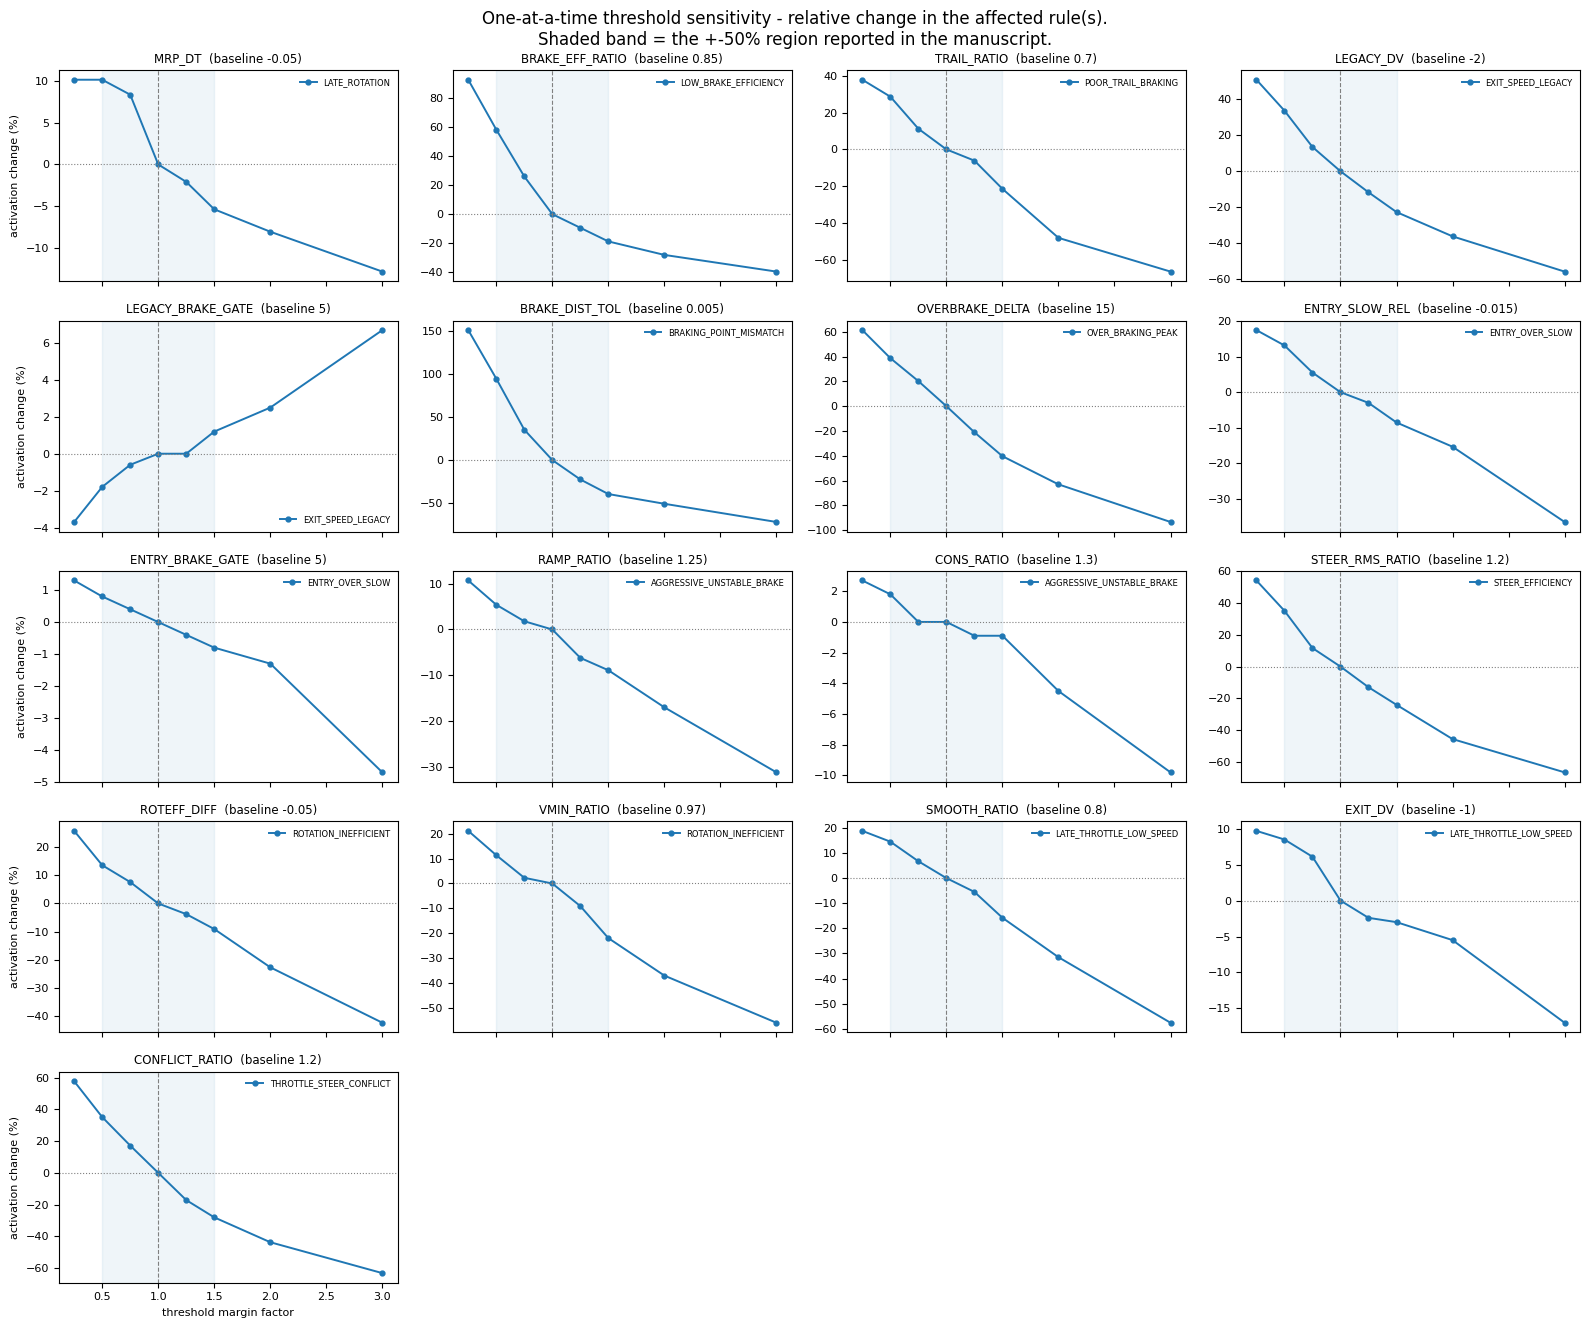

In [15]:
# --- OAT curves: relative change, comparable across panels ---------------------
params = list(THRESHOLD_SPEC)
ncols  = 4
nrows  = int(np.ceil(len(params) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), sharex=True)

for ax, param in zip(axes.flat, params):
    sub = df_act[df_act["Param"] == param]
    for rid, g in sub.groupby("Rule_ID"):
        g = g.sort_values("Factor")
        ax.plot(g["Factor"], g["RelChange_%"], marker="o", ms=3.5, lw=1.4, label=rid)
    ax.axvline(1.0, color="grey", lw=0.8, ls="--")
    ax.axhline(0.0, color="grey", lw=0.8, ls=":")
    ax.axvspan(0.5, 1.5, color="tab:blue", alpha=0.07)
    base = THRESHOLD_SPEC[param]
    ax.set_title(f"{param}  (baseline {base[0] + base[1]:.4g})", fontsize=8.5)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=6, frameon=False)

for ax in axes.flat[len(params):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("threshold margin factor", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("activation change (%)", fontsize=8)

fig.suptitle("One-at-a-time threshold sensitivity - relative change in the affected rule(s).\n"
             "Shaded band = the +-50% region reported in the manuscript.", fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_sensitivity_oat_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()

### 9.4 Joint Monte Carlo perturbation

All 17 factors drawn simultaneously from $\mathcal{U}(0.5, 1.5)$. Unlike OAT, every
rule moves in every draw, so Kendall tau against the baseline ranking is a real test.
Reported: the distribution of tau, of total activations, and the fraction of draws
in which the longitudinal pattern survives.

In [16]:
N_MC = 300
LO, HI = 0.5, 1.5

mc_rows = []
for i in range(N_MC):
    factors = {p: float(RNG.uniform(LO, HI)) for p in THRESHOLD_SPEC}
    df_s = evaluate_rules(pair_cache, thresholds_at(factors))
    summ, _ = scenario_summary(df_s, base_rank)
    mc_rows.append({"Draw": i, **summ})

df_mc = pd.DataFrame(mc_rows)
df_mc.to_csv(SAVE_DIR / "sensitivity_joint_montecarlo.csv", index=False)

q = df_mc["KendallTau"].quantile([0.05, 0.5, 0.95])
keep = float((df_mc["preserved"] == True).mean())
print(f"=== Joint perturbation: {N_MC} draws, all thresholds ~ U({LO}, {HI}) ===")
print(f"Kendall tau   : median {q[0.5]:.3f} | 5th pct {q[0.05]:.3f} | min {df_mc['KendallTau'].min():.3f}")
print(f"Total activ.  : median {df_mc['Total'].median():.0f} "
      f"(baseline {base_stats['Total']}), range {df_mc['Total'].min()}-{df_mc['Total'].max()}")
print(f"Feedback slope: median {df_mc['slope_fb'].median():+.2f} "
      f"(baseline {base_stats['slope_fb']:+.2f}), "
      f"negative in {100 * (df_mc['slope_fb'] < 0).mean():.1f}% of draws")
print(f"Pattern preserved in {100 * keep:.1f}% of draws")
display(df_mc[["KendallTau", "Total", "slope_fb", "slope_ctrl", "margin"]].describe().round(3))

=== Joint perturbation: 300 draws, all thresholds ~ U(0.5, 1.5) ===
Kendall tau   : median 0.779 | 5th pct 0.606 | min 0.515
Total activ.  : median 1840 (baseline 1815), range 1663-2048
Feedback slope: median -1.84 (baseline -2.15), negative in 100.0% of draws
Pattern preserved in 100.0% of draws


,KendallTau,Total,slope_fb,slope_ctrl,margin
count,300.000,300.000,300.000,300.000,300.000
mean,0.772,1842.870,-1.853,0.932,2.785
std,0.085,67.553,0.188,0.372,0.395
min,0.515,1663.000,-2.350,0.100,1.662
25%,0.718,1796.250,-2.000,0.650,2.509
50%,0.779,1840.000,-1.844,0.950,2.787
75%,0.842,1884.000,-1.713,1.163,3.053
max,0.992,2048.000,-1.337,2.050,3.875


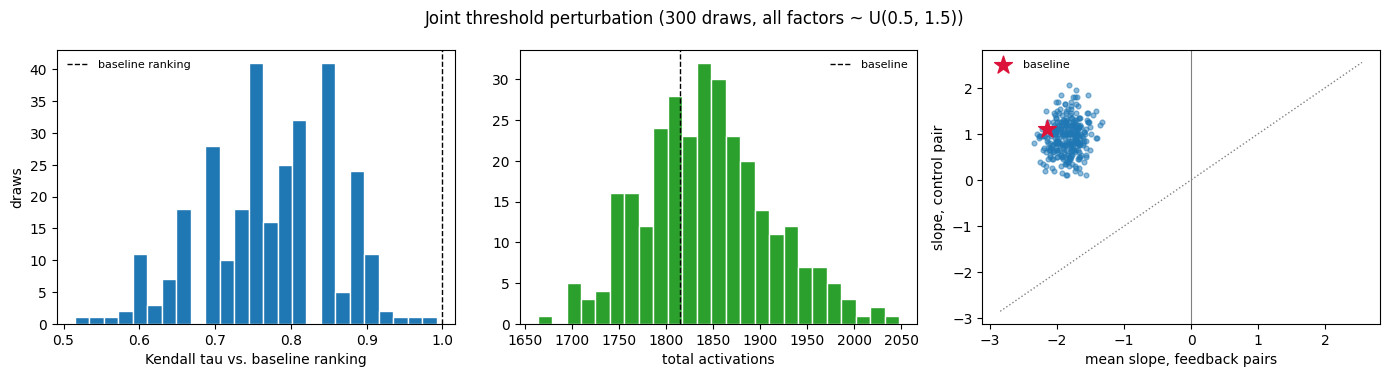

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(df_mc["KendallTau"], bins=25, color="tab:blue", edgecolor="white")
axes[0].axvline(1.0, color="k", ls="--", lw=1, label="baseline ranking")
axes[0].set_xlabel("Kendall tau vs. baseline ranking")
axes[0].set_ylabel("draws")
axes[0].legend(fontsize=8, frameon=False)

axes[1].hist(df_mc["Total"], bins=25, color="tab:green", edgecolor="white")
axes[1].axvline(base_stats["Total"], color="k", ls="--", lw=1, label="baseline")
axes[1].set_xlabel("total activations")
axes[1].legend(fontsize=8, frameon=False)

axes[2].scatter(df_mc["slope_fb"], df_mc["slope_ctrl"], s=12, alpha=0.5)
lim = [min(df_mc["slope_fb"].min(), df_mc["slope_ctrl"].min()) - 0.5,
       max(df_mc["slope_fb"].max(), df_mc["slope_ctrl"].max()) + 0.5]
axes[2].plot(lim, lim, color="grey", ls=":", lw=1)
axes[2].axvline(0, color="grey", lw=0.8)
axes[2].scatter([base_stats["slope_fb"]], [base_stats["slope_ctrl"]],
                marker="*", s=180, color="crimson", zorder=5, label="baseline")
axes[2].set_xlabel("mean slope, feedback pairs")
axes[2].set_ylabel("slope, control pair")
axes[2].legend(fontsize=8, frameon=False)

fig.suptitle(f"Joint threshold perturbation ({N_MC} draws, all factors ~ U({LO}, {HI}))",
             fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_sensitivity_joint_mc.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 10. Descriptor-level sweep — `PEDAL_ACTIVE_PCT` and `MIN_BRAKE_RUN`

These were invisible to the v2 analysis because they change the *descriptors*, not the
rules — no amount of rewriting `TH` reaches them. Yet `PEDAL_ACTIVE_PCT` feeds four
descriptors and is arguably the single most influential constant in the pipeline, so
leaving it out would be the first thing a careful reviewer noticed.

Each setting requires recomputing descriptors from the cached telemetry (seconds, not
minutes, since `.ibt` files are not reloaded).

=== Descriptor-level sensitivity ===


,Param,Value,Total,KendallTau,slope_fb,slope_ctrl,margin,preserved
0,PEDAL_ACTIVE_PCT,1.0,1838,0.97,-2.163,1.30,3.463,True
1,PEDAL_ACTIVE_PCT,2.5,1837,0.97,-2.163,1.35,3.512,True
2,PEDAL_ACTIVE_PCT,5.0,1815,1.00,-2.150,1.10,3.250,True
3,PEDAL_ACTIVE_PCT,7.5,1799,1.00,-2.125,1.25,3.375,True
4,PEDAL_ACTIVE_PCT,10.0,1787,1.00,-2.150,1.25,3.400,True
5,MIN_BRAKE_RUN,3.0,1839,1.00,-2.213,1.30,3.513,True
6,MIN_BRAKE_RUN,5.0,1815,1.00,-2.150,1.10,3.250,True
7,MIN_BRAKE_RUN,7.0,1814,1.00,-2.150,1.05,3.200,True
8,MIN_BRAKE_RUN,9.0,1810,1.00,-2.150,1.10,3.250,True


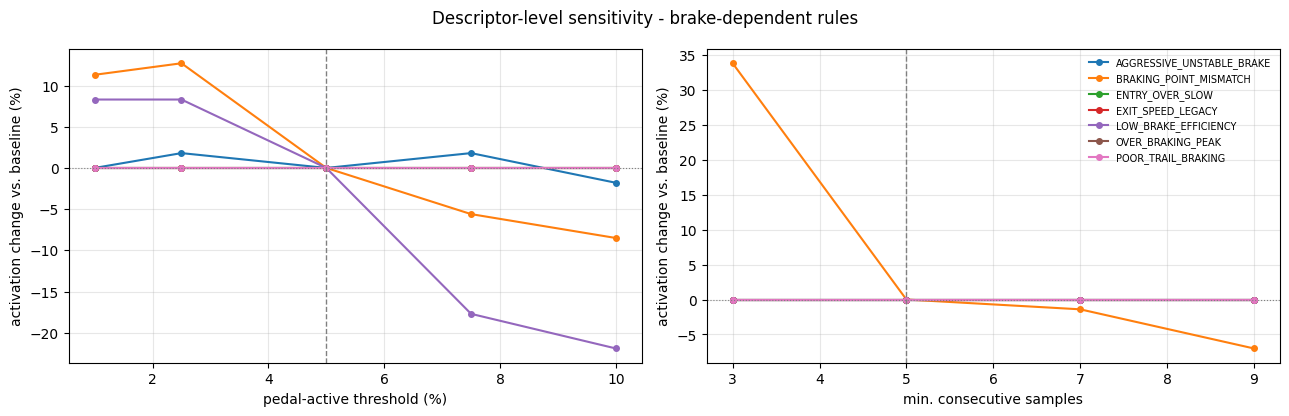

In [18]:
PEDAL_GRID = [1.0, 2.5, 5.0, 7.5, 10.0]     # %  (baseline 5.0)
RUN_GRID   = [3, 5, 7, 9]                    # samples (baseline 5)

desc_rows, desc_act = [], []
for name, grid_vals, key in (("PEDAL_ACTIVE_PCT", PEDAL_GRID, "PEDAL_ACTIVE_PCT"),
                             ("MIN_BRAKE_RUN",    RUN_GRID,   "MIN_BRAKE_RUN")):
    for val in grid_vals:
        dp = dict(DESC_SPEC, **{key: val})
        if dp == DESC_SPEC:
            df_s, summ = df_sector, base_stats
        else:
            pc   = build_pair_cache(build_heur_cache(dp))
            df_s = evaluate_rules(pc, thresholds_at())
            summ, _ = scenario_summary(df_s, base_rank)
        tot = df_s.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
        desc_rows.append({"Param": name, "Value": val, **summ})
        for rid in RULE_IDS:
            n0 = int(base_tot[rid])
            desc_act.append({"Param": name, "Value": val, "Rule_ID": rid,
                             "Activations": int(tot[rid]),
                             "RelChange_%": np.nan if n0 == 0 else
                                            round(100 * (tot[rid] - n0) / n0, 1)})

df_desc     = pd.DataFrame(desc_rows)
df_desc_act = pd.DataFrame(desc_act)
df_desc.to_csv(SAVE_DIR / "sensitivity_descriptor_params.csv", index=False)

print("=== Descriptor-level sensitivity ===")
display(df_desc.round(3))

# Brake-dependent rules are the ones that can move here.
BRAKE_RULES = ["BRAKING_POINT_MISMATCH", "LOW_BRAKE_EFFICIENCY",
               "AGGRESSIVE_UNSTABLE_BRAKE", "POOR_TRAIL_BRAKING",
               "OVER_BRAKING_PEAK", "ENTRY_OVER_SLOW", "EXIT_SPEED_LEGACY"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (name, xlabel) in zip(axes, [("PEDAL_ACTIVE_PCT", "pedal-active threshold (%)"),
                                     ("MIN_BRAKE_RUN", "min. consecutive samples")]):
    sub = df_desc_act[(df_desc_act["Param"] == name) &
                      (df_desc_act["Rule_ID"].isin(BRAKE_RULES))]
    for rid, g in sub.groupby("Rule_ID"):
        g = g.sort_values("Value")
        ax.plot(g["Value"], g["RelChange_%"], marker="o", ms=4, lw=1.5, label=rid)
    ax.axvline(DESC_SPEC[name], color="grey", ls="--", lw=1)
    ax.axhline(0, color="grey", ls=":", lw=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("activation change vs. baseline (%)")
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=7, frameon=False, loc="best")
fig.suptitle("Descriptor-level sensitivity - brake-dependent rules", fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_sensitivity_descriptor.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 11. Negative control — self-comparison

Specificity check: comparing Driver B's own stints against Driver B's reference lap
should activate far fewer rules than a cross-driver comparison, since only
intra-driver variability remains.

Computed under **both** threshold sets. The prediction is that the corrected
thresholds separate self from cross-driver more cleanly, because a large share of the
pre-correction self-activations came from `OVER_BRAKING_PEAK` firing on a 0.15 p.p.
margin — i.e. on pedal noise. If the prediction holds, the correction improved the
engine's specificity, which is a point worth making in the response letter.

In [19]:
SELF = {"ref": "Tomaz", "ref_stint": "stint_ref", "test": "Tomaz",
        "label": "B vs. B (self)"}


def self_pair_cache(dp):
    out = {}
    for track, cfg in DATASETS.items():
        if SELF["test"] not in cfg["sessions"] or SELF["ref"] not in cfg["sessions"]:
            continue
        edges = TRACK_CONFIGS[track]["custom_edges"]
        try:
            interp_ref = load_best_lap_interp(track, SELF["ref"], SELF["ref_stint"])[0]
        except Exception as e:
            print(f"[SKIP] {track} self ref -> {e}")
            continue
        heur_ref = compute_sector_heuristics(interp_ref, edges, dp)
        for stint in sorted(k for k in cfg["sessions"][SELF["test"]] if k not in EXCLUDE_STINTS):
            try:
                interp_t = load_best_lap_interp(track, SELF["test"], stint)[0]
            except Exception as e:
                print(f"[SKIP] {track} self {stint} -> {e}")
                continue
            heur_t = compute_sector_heuristics(interp_t, edges, dp)
            out[(TRACK_SHORT[track], SELF["label"], stint)] = (heur_ref, heur_t)
    return build_pair_cache(out)


rows = []
for tag, dp, spec in (("Corrected (v3)", DESC_SPEC, THRESHOLD_SPEC),
                      ("Legacy (v2)",    DESC_LEGACY, THRESHOLD_SPEC_LEGACY)):
    pc     = self_pair_cache(dp)
    df_s   = evaluate_rules(pc, thresholds_at(spec=spec))
    self_t = df_s.groupby(["Track", "Stint"])["Fired"].sum()
    cross  = (df_sector if tag.startswith("Corrected") else df_legacy)
    cross_t = cross.groupby(["Track", "Comparison", "Stint"])["Fired"].sum()
    rows.append({"Thresholds": tag,
                 "Self mean":  round(self_t.mean(), 1),
                 "Self max":   int(self_t.max()),
                 "Cross mean": round(cross_t.mean(), 1),
                 "Cross min":  int(cross_t.min()),
                 "Ratio":      round(cross_t.mean() / max(self_t.mean(), 1e-9), 2)})
    if tag.startswith("Corrected"):
        df_self_detail = self_t.reset_index(name="Activations")
        df_self_rules  = df_s.groupby("Rule_ID")["Fired"].sum().sort_values(ascending=False)

df_ctrl = pd.DataFrame(rows)
print("=== Negative control: self vs cross-driver activations per stint ===")
display(df_ctrl)
print("\nSelf-comparison activations per stint (corrected thresholds):")
display(df_self_detail)
print("\nWhich rules still fire on self-comparison (corrected):")
print(df_self_rules.astype(int).to_string())
df_ctrl.to_csv(SAVE_DIR / "negative_control_summary.csv", index=False)

=== Negative control: self vs cross-driver activations per stint ===


,Thresholds,Self mean,Self max,Cross mean,Cross min,Ratio
0,Corrected (v3),25.1,39,36.3,14,1.45
1,Legacy (v2),27.6,42,38.9,16,1.41



Self-comparison activations per stint (corrected thresholds):


,Track,Stint,Activations
0,CLT,stint_1,31
1,CLT,stint_2,39
2,CLT,stint_3,26
3,CLT,stint_4,38
4,CLT,stint_5,27
5,SPT,stint_1,22
6,SPT,stint_2,21
7,SPT,stint_3,14
8,SPT,stint_4,22
9,SPT,stint_5,11



Which rules still fire on self-comparison (corrected):
Rule_ID
LATE_ROTATION                81
ENTRY_OVER_SLOW              29
STEER_EFFICIENCY             28
THROTTLE_STEER_CONFLICT      23
LATE_THROTTLE_LOW_SPEED      21
POOR_TRAIL_BRAKING           18
EXIT_SPEED_LEGACY            14
LOW_BRAKE_EFFICIENCY         14
ROTATION_INEFFICIENT          8
BRAKING_POINT_MISMATCH        7
AGGRESSIVE_UNSTABLE_BRAKE     6
OVER_BRAKING_PEAK             2


## 12. Convergent validity — activations vs. sector time loss

If the heuristics capture genuine causes of time loss, sectors **with** an activation
should concentrate larger $\Delta t$ than sectors without, and the activation count
should correlate positively with sector $\Delta t$.

This is the strongest empirical answer available to "not independently validated": it
does not assume the thresholds are right, it tests whether their output tracks an
outcome measured independently of them.

Sector pairs analysed          : 700
Spearman rho (N_Act vs DeltaT) : 0.375  (p = 7.64e-25)
Median DeltaT | no activation  : 0.019 s  (n = 33)
Median DeltaT | >=1 activation : 0.148 s  (n = 667)
Mann-Whitney U (one-sided)     : p = 1.53e-06
Cliff's delta                  : 0.481

Per-comparison Spearman rho:


,Track,Comparison,Spearman_rho
0,CLT,B vs. A,0.249
1,CLT,C vs. B,0.498
2,CLT,D vs. B,0.421
3,CLT,E vs. B,0.367
4,CLT,F vs. B,0.490
5,SPT,B vs. A,0.676
6,SPT,C vs. B,0.603
7,SPT,D vs. B,0.011
8,SPT,E vs. B,0.325
9,SPT,F vs. B,0.410


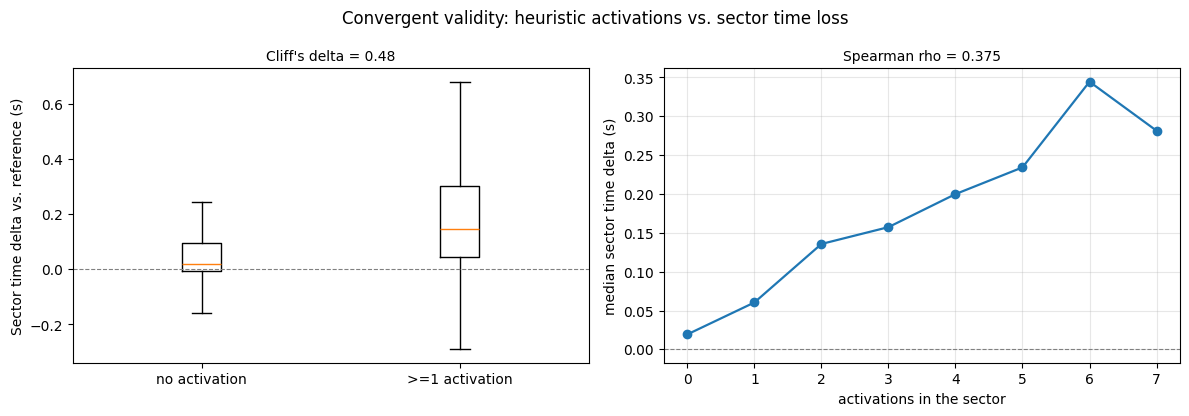

In [20]:
from scipy.stats import spearmanr, mannwhitneyu

sector_act = (df_sector.groupby(["Track", "Comparison", "Stint", "Sector"])["Fired"]
              .sum().reset_index(name="N_Act"))
dt_rows = [{"Track": t, "Comparison": c, "Stint": s, "Sector": sec, "DeltaT_s": dts}
           for (t, c, s), pairs in pair_cache.items()
           for sec, A, B, dts in pairs]
df_conv = (sector_act.merge(pd.DataFrame(dt_rows),
                            on=["Track", "Comparison", "Stint", "Sector"], how="inner")
           .dropna(subset=["DeltaT_s"]))

rho, p_rho = spearmanr(df_conv["N_Act"], df_conv["DeltaT_s"])
g0 = df_conv.loc[df_conv["N_Act"] == 0, "DeltaT_s"]
g1 = df_conv.loc[df_conv["N_Act"] > 0, "DeltaT_s"]
u_stat, p_u = mannwhitneyu(g1, g0, alternative="greater")
cliffs = 2 * u_stat / (len(g0) * len(g1)) - 1   # Cliff's delta

print(f"Sector pairs analysed          : {len(df_conv)}")
print(f"Spearman rho (N_Act vs DeltaT) : {rho:.3f}  (p = {p_rho:.2e})")
print(f"Median DeltaT | no activation  : {g0.median():.3f} s  (n = {len(g0)})")
print(f"Median DeltaT | >=1 activation : {g1.median():.3f} s  (n = {len(g1)})")
print(f"Mann-Whitney U (one-sided)     : p = {p_u:.2e}")
print(f"Cliff's delta                  : {cliffs:.3f}")

per_comp = (df_conv.groupby(["Track", "Comparison"])[["N_Act", "DeltaT_s"]]
            .apply(lambda g: spearmanr(g["N_Act"], g["DeltaT_s"])[0] if len(g) > 5 else np.nan)
            .rename("Spearman_rho").reset_index())
print("\nPer-comparison Spearman rho:")
display(per_comp.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].boxplot([g0, g1], tick_labels=["no activation", ">=1 activation"], showfliers=False)
axes[0].axhline(0, color="grey", lw=0.8, ls="--")
axes[0].set_ylabel("Sector time delta vs. reference (s)")
axes[0].set_title(f"Cliff's delta = {cliffs:.2f}", fontsize=10)

by_n = df_conv.groupby("N_Act")["DeltaT_s"].agg(["median", "count"])
by_n = by_n[by_n["count"] >= 5]
axes[1].plot(by_n.index, by_n["median"], marker="o", lw=1.6)
axes[1].axhline(0, color="grey", lw=0.8, ls="--")
axes[1].set_xlabel("activations in the sector")
axes[1].set_ylabel("median sector time delta (s)")
axes[1].set_title(f"Spearman rho = {rho:.3f}", fontsize=10)
axes[1].grid(alpha=0.3)

fig.suptitle("Convergent validity: heuristic activations vs. sector time loss", fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_convergent_validity.pdf", dpi=300, bbox_inches="tight")
plt.show()
df_conv.to_csv(SAVE_DIR / "convergent_validity_sector_level.csv", index=False)
per_comp.to_csv(SAVE_DIR / "convergent_validity_per_comparison.csv", index=False)

## 13. Consolidated summary for the response letter

In [21]:
summary = {
    "Sector pairs analysed":          len(df_conv),
    "Total activations (baseline)":   int(base_stats["Total"]),
    "OAT scenarios":                  int(len(pert)),
    "OAT pattern preserved":          f"{n_keep}/{len(pert)}",
    "OAT Kendall tau (min)":          round(float(pert["KendallTau"].min()), 3),
    "MC draws":                       N_MC,
    "MC Kendall tau (median)":        round(float(df_mc["KendallTau"].median()), 3),
    "MC Kendall tau (5th pct)":       round(float(df_mc["KendallTau"].quantile(0.05)), 3),
    "MC pattern preserved":           f"{100 * float((df_mc['preserved'] == True).mean()):.1f}%",
    "Self vs cross ratio (corrected)": float(df_ctrl.loc[df_ctrl['Thresholds'].str.startswith('Corrected'), 'Ratio'].iloc[0]),
    "Self vs cross ratio (legacy)":    float(df_ctrl.loc[df_ctrl['Thresholds'].str.startswith('Legacy'), 'Ratio'].iloc[0]),
    "Spearman rho (activations~dt)":  round(float(rho), 3),
    "Cliff's delta (dt | activation)": round(float(cliffs), 3),
}
df_summary = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df_summary.to_csv(SAVE_DIR / "response_letter_summary.csv", index=False)
display(df_summary)
print(f"\nAll artifacts saved to: {SAVE_DIR}")

,Metric,Value
0,Sector pairs analysed,700
1,Total activations (baseline),1815
2,OAT scenarios,119
3,OAT pattern preserved,119/119
4,OAT Kendall tau (min),0.727
5,MC draws,300
6,MC Kendall tau (median),0.779
7,MC Kendall tau (5th pct),0.606
8,MC pattern preserved,100.0%
9,Self vs cross ratio (corrected),1.45



All artifacts saved to: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_heuristics_v3


## 14. Notes for the manuscript and the response letter

### Manuscript edits implied by this notebook

1. **Table 2** — add the unit convention stated in §3 and correct the units of
   `Delta_MRP_Vmin` (s), `RotationEfficiency` (s⁻¹) and `ThrottleSmoothness` ((%/s)⁻²).
2. **Table 3** — `LATE_ROTATION` reads −0.05 s (not −5 %); `ROTATION_INEFFICIENT`
   reads −0.05 s⁻¹ and 0.97× (not 0.97 %); `OVER_BRAKING_PEAK` reads +15 p.p.;
   `BRAKING_POINT_MISMATCH` reads 0.005 in lap fraction.
3. **Section 4.2** — use one term throughout for the origin of the thresholds
   (*expert-elicited* is the suggestion), and cross-reference the limitation and the
   future-work statement so the reader sees a single thread rather than three
   scattered remarks.
4. **Results** — Table 7 and Figures 8–10 must be regenerated from this notebook;
   the pre-correction numbers were computed with thresholds the manuscript did not
   declare.
5. **New appendix** — sensitivity (§9), negative control (§11) and convergent
   validity (§12).

### What each section answers

| Reviewer concern | Section |
|---|---|
| "inconsistencies in definitions and units remain" | §3, §6 |
| "thresholds not independently validated" | §9 (robustness), §12 (convergent validity) |
| implicit: is the engine specific, or does it fire on anything? | §11 |

### Framing

The thresholds encode prior race-engineering knowledge; no claim of external validity
is made for the specific numeric values. What the analysis above supports is weaker
and more defensible: the *conclusions* do not depend on the exact values, and the
activations track an independently measured outcome. Full validation against
instructor ratings or a controlled learning study remains future work, as already
stated in the Limitations.